In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print(os.getcwd())   # should end in project_data

import cv2
import pandas as pd
import matplotlib.pyplot as plt

single = pd.read_csv("data/generated/single_metadata.csv")
scenes = pd.read_csv("data/generated/scenes_metadata.csv")

print(single.groupby(["split", "label"]).size())
print(scenes.groupby("split").size())
print(len(single), len(scenes))   # expected: 1250 140

d:\project_data
split  label   
test   circle       50
       hexagon      50
       pentagon     50
       square       50
       triangle     50
train  circle      200
       hexagon     200
       pentagon    200
       square      200
       triangle    200
dtype: int64
split
test      40
train    100
dtype: int64
1250 140


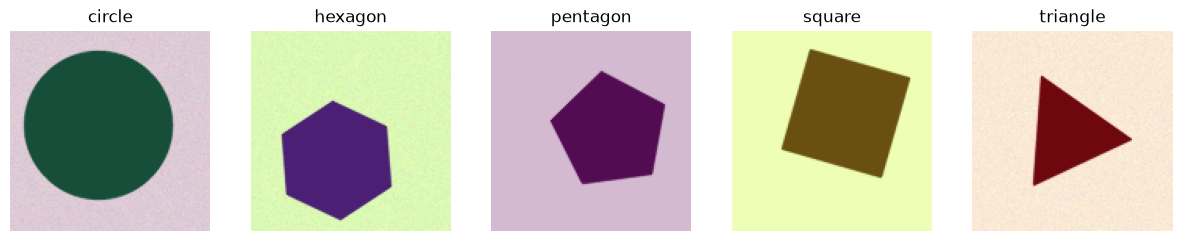

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (label, g) in zip(axes, single[single.split == "train"].groupby("label")):
    img = cv2.imread(g.iloc[0].path)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(label)
    ax.axis("off")
os.makedirs("outputs", exist_ok=True)
fig.savefig("outputs/generated_samples.png", dpi=150, bbox_inches="tight")
plt.show()

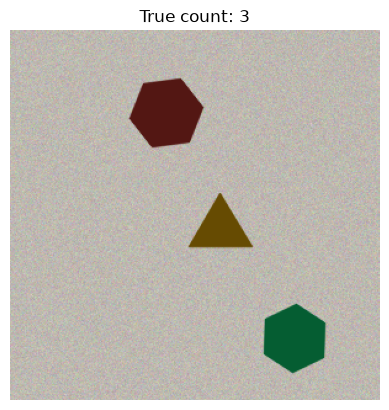

In [3]:
row = scenes.iloc[0]
plt.imshow(cv2.cvtColor(cv2.imread(row.path), cv2.COLOR_BGR2RGB))
plt.title(f"True count: {row.total_count}")
plt.axis("off")
plt.savefig("outputs/generated_scene_example.png", dpi=150, bbox_inches="tight")
plt.show()